In [3]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import shutil
from PIL import Image, ImageEnhance, ImageFilter
import numpy as np
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  0


In [5]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

CUDA available: True
GPU Name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [9]:
def analyze_images(folder_path):
    image_count = 0
    resolutions = {}
    formats = {}

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            try:
                image_path = os.path.join(root, file)
                with Image.open(image_path) as img:
                    image_count += 1

                    resolution = img.size 
                    resolutions[resolution] = resolutions.get(resolution, 0) + 1

                    img_format = img.format
                    formats[img_format] = formats.get(img_format, 0) + 1
            except Exception as e:
                print(f"Error processing file {file}: {e}")

    return image_count, resolutions, formats


train_folder = r"E:\Teju\dataset\train_images"
test_folder = r"E:\Teju\dataset\test_images"

print("Analyzing Training Dataset...")
train_count, train_resolutions, train_formats = analyze_images(train_folder)
print(f"Total Training Images: {train_count}")
print(f"Training Image Resolutions: {train_resolutions}")
print(f"Training Image Formats: {train_formats}")

Analyzing Training Dataset...
Total Training Images: 3632
Training Image Resolutions: {(3216, 2136): 410, (2416, 1736): 638, (1050, 1050): 974, (2048, 1536): 351, (3388, 2588): 141, (2588, 1958): 503, (819, 614): 287, (1504, 1000): 92, (1844, 1226): 61, (4288, 2848): 52, (640, 480): 42, (2896, 1944): 34, (2144, 1424): 28, (1476, 1117): 14, (474, 358): 2, (2146, 1764): 1, (1467, 1110): 2}
Training Image Formats: {'PNG': 3632}


In [11]:
print("\nAnalyzing Testing Dataset...")
test_count, test_resolutions, test_formats = analyze_images(test_folder)
print(f"Total Testing Images: {test_count}")
print(f"Testing Image Resolutions: {test_resolutions}")
print(f"Testing Image Formats: {test_formats}")


Analyzing Testing Dataset...
Total Testing Images: 1928
Testing Image Resolutions: {(640, 480): 1403, (2416, 1736): 225, (1050, 1050): 69, (2588, 1958): 134, (819, 614): 45, (2896, 1944): 11, (2048, 1536): 28, (768, 576): 2, (2592, 1944): 6, (1467, 1110): 2, (2146, 1764): 1, (1476, 1117): 2}
Testing Image Formats: {'PNG': 1928}


In [13]:
def analyze_csv(file_path, dataset_name):
    try:
        data = pd.read_csv(file_path)

        print(f"\nAnalyzing {dataset_name} Dataset Metadata...")
        print(f"Number of Rows: {data.shape[0]}")
        print(f"Number of Columns: {data.shape[1]}")
        print("\nColumn Names:")
        print(data.columns)

        print("\nMissing Values Per Column:")
        print(data.isnull().sum())

        print("\nUnique Values in Each Column:")
        for column in data.columns:
            print(f"{column}: {data[column].nunique()} unique values")

        if 'label' in data.columns or 'diagnosis' in data.columns:  # Assuming the column might be 'label' or 'diagnosis'
            label_column = 'label' if 'label' in data.columns else 'diagnosis'
            print(f"\nDistribution of {label_column} Labels:")
            print(data[label_column].value_counts())

    except Exception as e:
        print(f"Error reading {file_path}: {e}")


train_csv = r"E:\Teju\dataset\train.csv"
test_csv = r"E:\Teju\dataset\test.csv"

analyze_csv(train_csv, "Training")


Analyzing Training Dataset Metadata...
Number of Rows: 3662
Number of Columns: 2

Column Names:
Index(['id_code', 'diagnosis'], dtype='object')

Missing Values Per Column:
id_code      0
diagnosis    0
dtype: int64

Unique Values in Each Column:
id_code: 3662 unique values
diagnosis: 5 unique values

Distribution of diagnosis Labels:
diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


In [15]:
analyze_csv(test_csv, "Testing")


Analyzing Testing Dataset Metadata...
Number of Rows: 1928
Number of Columns: 1

Column Names:
Index(['id_code'], dtype='object')

Missing Values Per Column:
id_code    0
dtype: int64

Unique Values in Each Column:
id_code: 1928 unique values


Class 0: 1805 samples


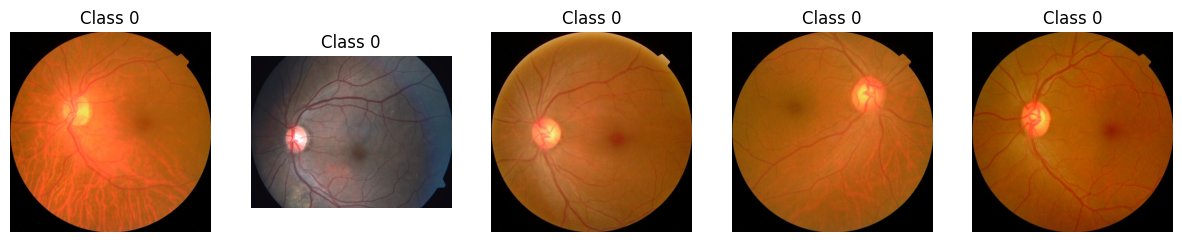

Class 1: 370 samples


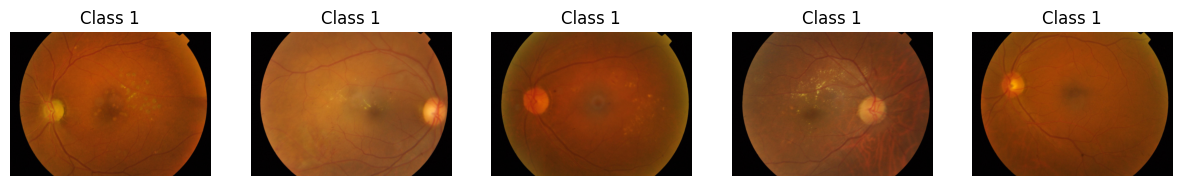

Class 2: 999 samples


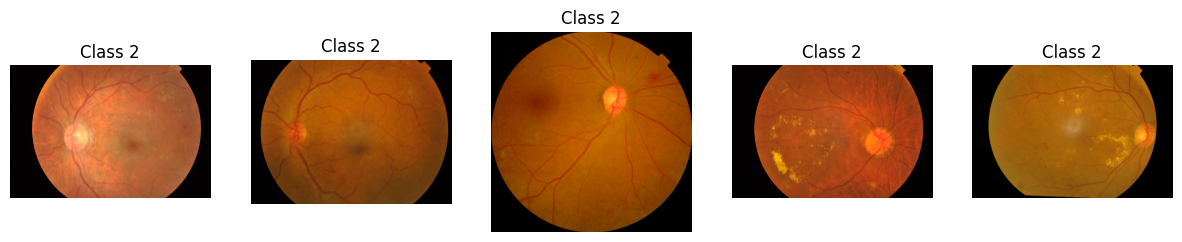

Class 3: 193 samples


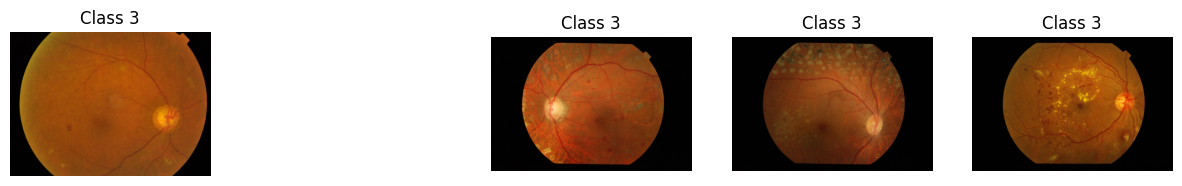

Class 4: 295 samples


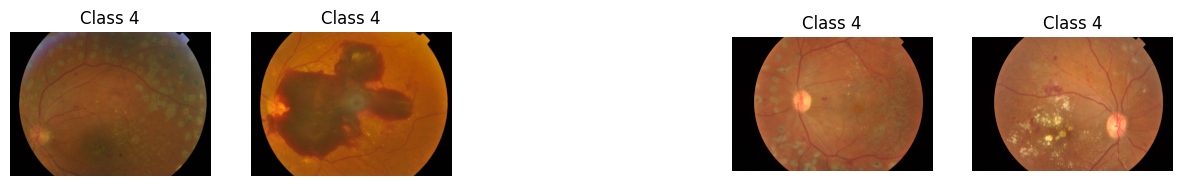

In [17]:
# Visualize sample images for each class
def visualize_samples(folder_path, csv_path, num_samples=5):
    import pandas as pd
    data = pd.read_csv(csv_path)
    diagnosis_groups = data.groupby('diagnosis')

    for diagnosis, group in diagnosis_groups:
        print(f"Class {diagnosis}: {len(group)} samples")
        sample_ids = group['id_code'].sample(num_samples, random_state=42).values
        plt.figure(figsize=(15, 5))
        for i, sample_id in enumerate(sample_ids):
            file_path = os.path.join(folder_path, f"{sample_id}.png")
            if os.path.exists(file_path):
                img = Image.open(file_path)
                plt.subplot(1, num_samples, i + 1)
                plt.imshow(img)
                plt.title(f"Class {diagnosis}")
                plt.axis('off')
        plt.show()

# Update the paths accordingly
train_folder = r"E:\Teju\dataset\train_images"
train_csv = r"E:\Teju\dataset\train.csv"

visualize_samples(train_folder, train_csv)


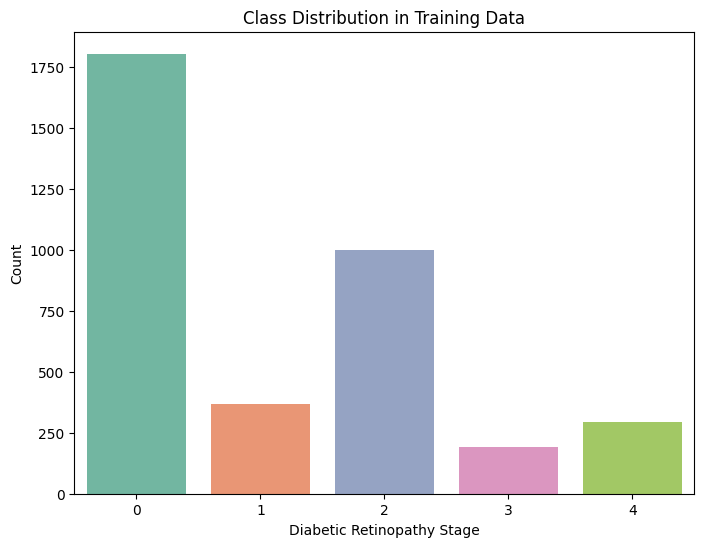

In [18]:
# Load training CSV
data = pd.read_csv(train_csv)

# Plot class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', hue='diagnosis', data=data, palette='Set2', legend=False)
plt.title("Class Distribution in Training Data")
plt.xlabel("Diabetic Retinopathy Stage")
plt.ylabel("Count")
plt.show()

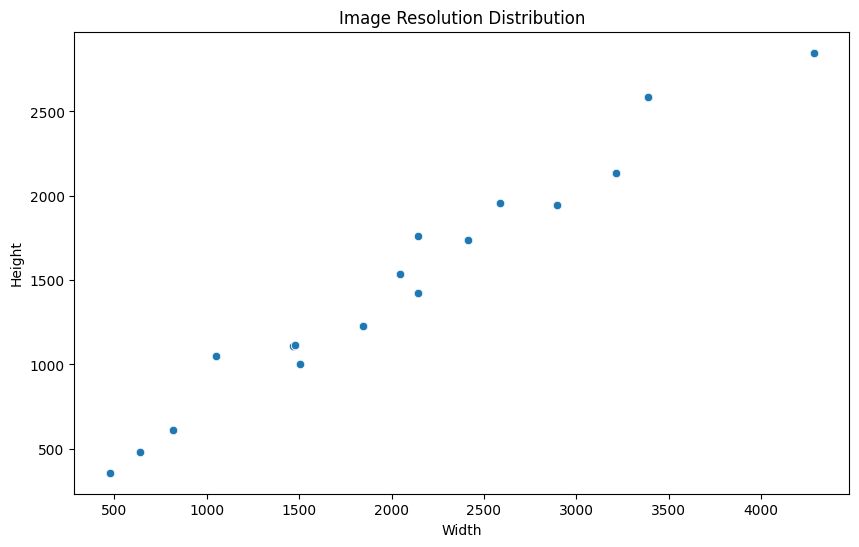

Image Resolution Summary:
             Width       Height
count  3632.000000  3632.000000
mean   2010.445209  1523.268722
std     886.407035   543.477367
min     474.000000   358.000000
25%    1050.000000  1050.000000
50%    2048.000000  1536.000000
75%    2588.000000  1958.000000
max    4288.000000  2848.000000


In [21]:
def image_statistics(folder_path):
    from PIL import Image
    resolutions = []
    
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            try:
                image_path = os.path.join(root, file)
                with Image.open(image_path) as img:
                    resolutions.append(img.size)
            except Exception as e:
                print(f"Error processing file {file}: {e}")
    
    return resolutions

# Analyze training images
resolutions = image_statistics(train_folder)
resolution_df = pd.DataFrame(resolutions, columns=['Width', 'Height'])

# Plot resolution distribution
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Width', y='Height', data=resolution_df)
plt.title("Image Resolution Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

# Summary statistics of resolutions
print("Image Resolution Summary:")
print(resolution_df.describe())

In [23]:
# Paths
train_folder = r"E:\Teju\dataset\train_images"
train_csv = r"E:\Teju\dataset\train.csv"
organized_train_folder = r"E:\Teju\dataset\organized_train"

# Create subfolders for each class
os.makedirs(organized_train_folder, exist_ok=True)
for i in range(5):  # Assuming classes are 0 to 4
    os.makedirs(os.path.join(organized_train_folder, f'class_{i}'), exist_ok=True)

# Load CSV
train_data = pd.read_csv(train_csv)

# Move images to corresponding subfolders
for _, row in train_data.iterrows():
    img_name = f"{row['id_code']}.png"
    class_label = row['diagnosis']
    source_path = os.path.join(train_folder, img_name)
    destination_path = os.path.join(organized_train_folder, f'class_{class_label}', img_name)
    
    if os.path.exists(source_path):
        shutil.move(source_path, destination_path)

print("Images have been successfully organized into class-specific subfolders!")


Images have been successfully organized into class-specific subfolders!


In [25]:
# Paths
input_folder = r"E:\Teju\dataset\organized_train"
output_folder = r"E:\Teju\dataset\preprocessed_train"
os.makedirs(output_folder, exist_ok=True)

# Parameters
output_size = (224, 224)  # Resize dimensions
std_dev_threshold = 16  # Standard deviation threshold for filtering

# Tracking flagged images
flagged_images = []

# Function to preprocess images
def preprocess_images(input_folder, output_folder, output_size, std_dev_threshold):
    print("Starting Image Preprocessing...")
    for class_name in os.listdir(input_folder):
        class_input_path = os.path.join(input_folder, class_name)
        class_output_path = os.path.join(output_folder, class_name)
        os.makedirs(class_output_path, exist_ok=True)

        print(f"\nProcessing {class_name}...")
        for img_name in tqdm(os.listdir(class_input_path), desc=f"Processing {class_name}"):
            input_path = os.path.join(class_input_path, img_name)
            output_path = os.path.join(class_output_path, img_name)

            try:
                # Open image
                img = Image.open(input_path).convert('RGB')

                # Normalize pixel values (scale to 0-1)
                img_array = np.array(img) / 255.0

                # Calculate standard deviation
                std_dev = np.std(img_array)

                # Flag dark images
                if std_dev < std_dev_threshold:
                    flagged_images.append((class_name, img_name))

                # Enhance contrast if flagged
                if std_dev < std_dev_threshold:
                    enhancer = ImageEnhance.Contrast(img)
                    img = enhancer.enhance(2.0)

                # Resize image
                img = img.resize(output_size)

                # Save preprocessed image
                img.save(output_path)
            except Exception as e:
                print(f"Error processing image {img_name}: {e}")

    print("\nImage Preprocessing Completed!")
    print(f"Total flagged (low contrast) images: {len(flagged_images)}")
    return flagged_images

# Run preprocessing
flagged_images = preprocess_images(input_folder, output_folder, output_size, std_dev_threshold)

# Print flagged images summary
if flagged_images:
    print("\nFlagged Images (low standard deviation):")
    for class_name, img_name in flagged_images[:10]:  # Show first 10
        print(f"Class: {class_name}, Image: {img_name}")
    print("...")

else:
    print("No images flagged as low contrast.")


Starting Image Preprocessing...

Processing class_0...


Processing class_0: 100%|██████████| 1794/1794 [05:29<00:00,  5.45it/s]



Processing class_1...


Processing class_1: 100%|██████████| 368/368 [02:21<00:00,  2.61it/s]



Processing class_2...


...


Processing class_3...


Processing class_3: 100%|██████████| 192/192 [01:09<00:00,  2.77it/s]



Processing class_4...


Processing class_4: 100%|██████████| 293/293 [01:54<00:00,  2.57it/s]


Image Preprocessing Completed!
Total flagged (low contrast) images: 3632

Flagged Images (low standard deviation):
Class: class_0, Image: 002c21358ce6.png
Class: class_0, Image: 005b95c28852.png
Class: class_0, Image: 0097f532ac9f.png
Class: class_0, Image: 00cc2b75cddd.png
Class: class_0, Image: 00f6c1be5a33.png
Class: class_0, Image: 0125fbd2e791.png
Class: class_0, Image: 014508ccb9cb.png
Class: class_0, Image: 0151781fe50b.png
Class: class_0, Image: 0182152c50de.png
Class: class_0, Image: 01d9477b1171.png
...


In [27]:
# Paths
input_folder = r"E:\Teju\dataset\preprocessed_train"
output_folder = r"E:\Teju\dataset\enhanced_train"
os.makedirs(output_folder, exist_ok=True)

# Parameters
crop_threshold = 40  # Grayscale intensity below this value is considered "dark"
contrast_factor = 1.5  # Factor by which to enhance contrast

# Function to crop dark regions
def crop_dark_regions(image, threshold):
    img_gray = image.convert('L')  # Convert to grayscale
    img_array = np.array(img_gray)
    mask = img_array > threshold  # Mask for valid pixels

    if not mask.any():  # If all pixels are below the threshold, return the original image
        return image

    # Find bounding box of non-dark pixels
    coords = np.argwhere(mask)
    x0, y0 = coords.min(axis=0)
    x1, y1 = coords.max(axis=0) + 1  # Add 1 for inclusive cropping
    cropped_img = image.crop((y0, x0, y1, x1))  # Note the PIL coordinates order
    return cropped_img

# Function to enhance contrast
def enhance_contrast(image, factor):
    enhancer = ImageEnhance.Contrast(image)
    return enhancer.enhance(factor)

# Function to process images
def process_images(input_folder, output_folder, crop_threshold, contrast_factor):
    print("Starting Contrast Enhancement and Cropping...")
    for class_name in os.listdir(input_folder):
        class_input_path = os.path.join(input_folder, class_name)
        class_output_path = os.path.join(output_folder, class_name)
        os.makedirs(class_output_path, exist_ok=True)

        print(f"\nProcessing {class_name}...")
        for img_name in tqdm(os.listdir(class_input_path), desc=f"Processing {class_name}"):
            input_path = os.path.join(class_input_path, img_name)
            output_path = os.path.join(class_output_path, img_name)

            try:
                # Open image
                img = Image.open(input_path)

                # Crop dark regions
                img = crop_dark_regions(img, crop_threshold)

                # Enhance contrast
                img = enhance_contrast(img, contrast_factor)

                # Resize back to consistent dimensions
                img = img.resize((224, 224))

                # Save processed image
                img.save(output_path)
            except Exception as e:
                print(f"Error processing image {img_name}: {e}")

    print("\nContrast Enhancement and Cropping Completed!")

# Run the processing
process_images(input_folder, output_folder, crop_threshold, contrast_factor)


Starting Contrast Enhancement and Cropping...

Processing class_0...


Processing class_0: 100%|██████████| 1794/1794 [00:49<00:00, 36.16it/s]



Processing class_1...


Processing class_1: 100%|██████████| 368/368 [00:10<00:00, 33.64it/s]



Processing class_2...


...


Processing class_3...


Processing class_3: 100%|██████████| 192/192 [00:05<00:00, 32.66it/s]



Processing class_4...


Processing class_4: 100%|██████████| 293/293 [00:08<00:00, 32.66it/s]


Contrast Enhancement and Cropping Completed!


Starting Data Augmentation...

Processing class_0 (Current: 1794, Target: 3000)...


Copying class_0: 100%|██████████| 1794/1794 [00:11<00:00, 154.32it/s]



Processing class_1 (Current: 368, Target: 3000)...


Copying class_1: 100%|██████████| 368/368 [00:02<00:00, 149.23it/s]



Processing class_2 (Current: 985, Target: 3000)...


...


Processing class_3 (Current: 192, Target: 3000)...


Copying class_3: 100%|██████████| 192/192 [00:01<00:00, 156.05it/s]



Processing class_4 (Current: 293, Target: 3000)...


Copying class_4: 100%|██████████| 293/293 [00:01<00:00, 162.92it/s]



Data Augmentation Completed!

Visualizing Augmented Samples...


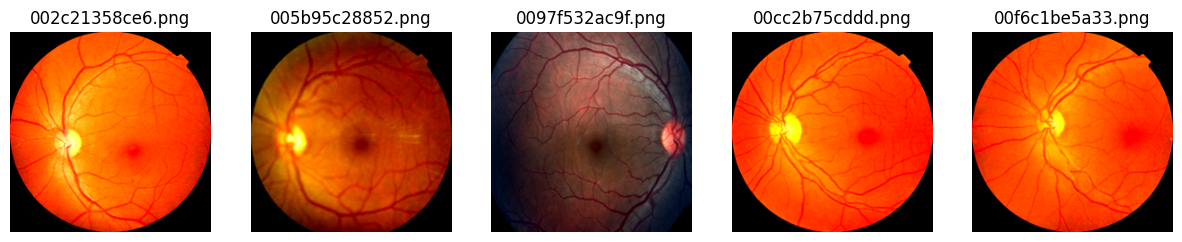

In [29]:
# Paths
input_folder = r"E:\Teju\dataset\enhanced_train"
output_folder = r"E:\Teju\dataset\augmented_train"
os.makedirs(output_folder, exist_ok=True)

# Target number of images per class
target_count = 3000

# Data augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2],
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Function to augment images for class balancing
def augment_class_images(input_folder, output_folder, target_count):
    print("Starting Data Augmentation...")
    for class_name in os.listdir(input_folder):
        class_input_path = os.path.join(input_folder, class_name)
        class_output_path = os.path.join(output_folder, class_name)
        os.makedirs(class_output_path, exist_ok=True)

        # Get list of existing images
        existing_images = os.listdir(class_input_path)
        current_count = len(existing_images)
        
        print(f"\nProcessing {class_name} (Current: {current_count}, Target: {target_count})...")
        
        # Copy existing images to output folder
        for img_name in tqdm(existing_images, desc=f"Copying {class_name}"):
            shutil.copy(os.path.join(class_input_path, img_name), os.path.join(class_output_path, img_name))
        
        # Augment images to reach target count
        if current_count < target_count:
            augment_needed = target_count - current_count
            image_idx = 0
            while augment_needed > 0:
                img_name = existing_images[image_idx % current_count]
                img_path = os.path.join(class_input_path, img_name)
                
                # Load image
                img = Image.open(img_path)
                img = img.resize((224, 224))  # Ensure consistent size
                img_array = np.expand_dims(np.array(img), axis=0)  # Add batch dimension

                # Generate augmented images
                batch_iter = datagen.flow(img_array, batch_size=1, save_to_dir=class_output_path, save_prefix='aug', save_format='png')
                for _ in batch_iter:
                    augment_needed -= 1
                    if augment_needed <= 0:
                        break
                image_idx += 1

    print("\nData Augmentation Completed!")

# Run data augmentation
augment_class_images(input_folder, output_folder, target_count)

# Visualize augmented samples
import matplotlib.pyplot as plt

def visualize_augmented_samples(class_folder, num_samples=5):
    print("\nVisualizing Augmented Samples...")
    sample_images = os.listdir(class_folder)[:num_samples]
    plt.figure(figsize=(15, 5))
    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(class_folder, img_name)
        img = plt.imread(img_path)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(img_name)
        plt.axis('off')
    plt.show()

# Visualize augmented samples from a specific class
sample_class_folder = os.path.join(output_folder, "class_0")  # Change class as needed
visualize_augmented_samples(sample_class_folder)



Visualizing Augmented Samples...

Class: class_0


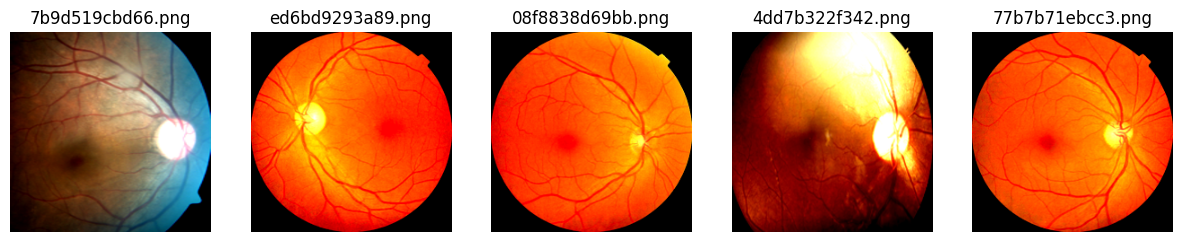


Class: class_1


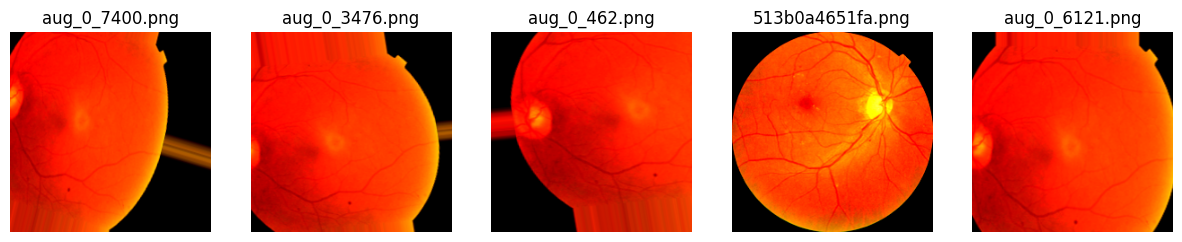


Class: class_2


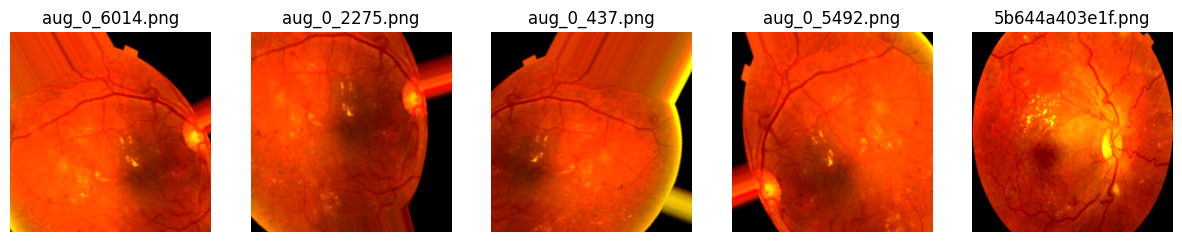


Class: class_3


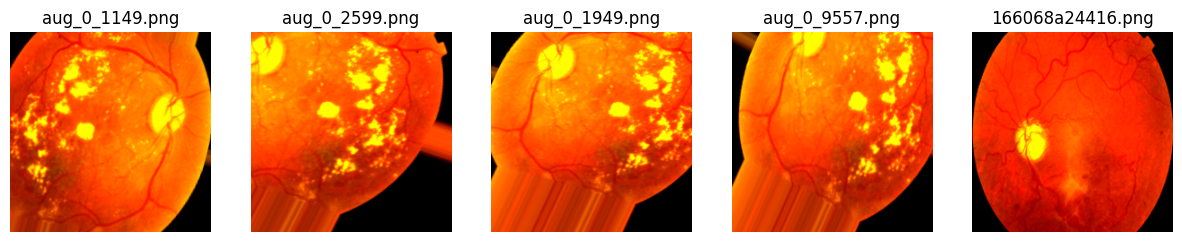


Class: class_4


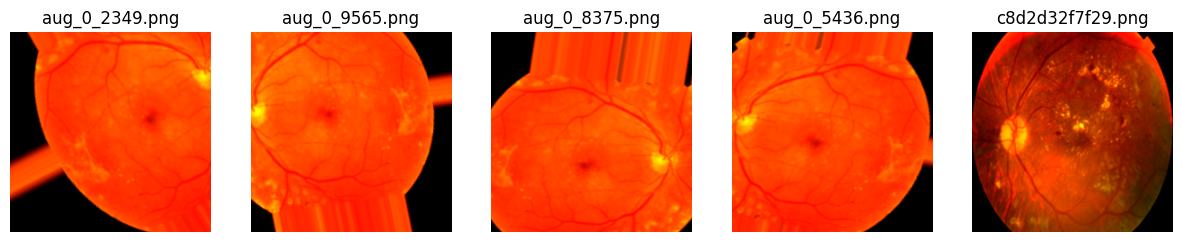

In [30]:
import os
import matplotlib.pyplot as plt
import random

# Paths
augmented_folder = r"E:\Teju\dataset\augmented_train"

def visualize_augmented_samples(folder_path, num_samples=5):
    print("\nVisualizing Augmented Samples...")
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        sample_images = random.sample(os.listdir(class_folder), num_samples)

        print(f"\nClass: {class_name}")
        plt.figure(figsize=(15, 5))
        for i, img_name in enumerate(sample_images):
            img_path = os.path.join(class_folder, img_name)
            img = plt.imread(img_path)
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            plt.title(img_name)
            plt.axis('off')
        plt.show()

# Visualize samples
visualize_augmented_samples(augmented_folder)


In [49]:
# Paths
train_data_dir = r"E:\Teju\dataset\augmented_train"

# Parameters
image_size = (224, 224)
batch_size = 32
num_classes = 5

# Data Generators
datagen = ImageDataGenerator(validation_split=0.2)  # 80% training, 20% validation

train_generator = datagen.flow_from_directory(
    train_data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    train_data_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 11016 images belonging to 5 classes.
Found 2752 images belonging to 5 classes.


In [67]:
print(train_generator.class_indices)
print(val_generator.class_indices)

{'class_0': 0, 'class_1': 1, 'class_2': 2, 'class_3': 3, 'class_4': 4}
{'class_0': 0, 'class_1': 1, 'class_2': 2, 'class_3': 3, 'class_4': 4}


In [73]:
import os

for i in range(num_classes):
    class_path = os.path.join(train_data_dir, f'class_{i}')
    image_count = len(os.listdir(class_path))
    print(f"Class {i}: {image_count}")

Class 0: 2925
Class 1: 2692
Class 2: 2832
Class 3: 2635
Class 4: 2684


In [75]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights
class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)

# Convert to a dictionary
class_weight_dict = dict(enumerate(class_weights))


In [77]:
# Model Architecture
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2

def build_model(input_shape=(224, 224, 3), num_classes=5):
    model = Sequential([
        Input(shape=input_shape),
        Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),  # L2 regularization added
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),  # L2 regularization added
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),  # L2 regularization added
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.01)),  # Increased neurons, L2 regularization added
        Dropout(0.5),  # You can adjust the dropout rate if needed
        Dense(128, activation='relu', kernel_regularizer=l2(0.01)),  # Added another Dense layer with L2 regularization
        Dropout(0.3),  # Added another Dropout layer with a lower rate
        Dense(num_classes, activation='softmax') 
    ])
    return model
# Compile Model
# Build the model
model = build_model() 

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,278,213 (84.98 MB)

 Trainable params: 22,278,213 (84.98 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)  # Increased patience
model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1, min_lr=1e-6)  # Increased patience

In [83]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,  # You can adjust the number of epochs
    callbacks=[early_stopping, model_checkpoint, lr_scheduler]
    # class_weight=class_weight_dict  # Remove or comment out this line
)

Epoch 1/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 169s 486ms/step - accuracy: 0.4812 - loss: 21.8635 - val_accuracy: 0.6904 - val_loss: 5.3157 - learning_rate: 0.0010
Epoch 2/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 168s 487ms/step - accuracy: 0.8530 - loss: 4.2510 - val_accuracy: 0.7333 - val_loss: 3.5081 - learning_rate: 0.0010
Epoch 3/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 168s 488ms/step - accuracy: 0.9074 - loss: 2.7376 - val_accuracy: 0.7267 - val_loss: 2.7361 - learning_rate: 0.0010
Epoch 4/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 170s 492ms/step - accuracy: 0.9312 - loss: 2.0129 - val_accuracy: 0.7500 - val_loss: 2.2481 - learning_rate: 0.0010
Epoch 5/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 169s 490ms/step - accuracy: 0.9290 - loss: 1.6876 - val_accuracy: 0.7242 - val_loss: 2.2523 - learning_rate: 0.0010
Epoch 6/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 168s 488ms/step - accuracy: 0.9348 - loss: 1.5627 - val_accuracy: 0.7089 - val_loss: 2.2075 - learning_rate: 0.0010
Epoch 7/50
345/345 ━━━━━━━━━━━━━━━━━━━━ 169s 489ms/step - accur

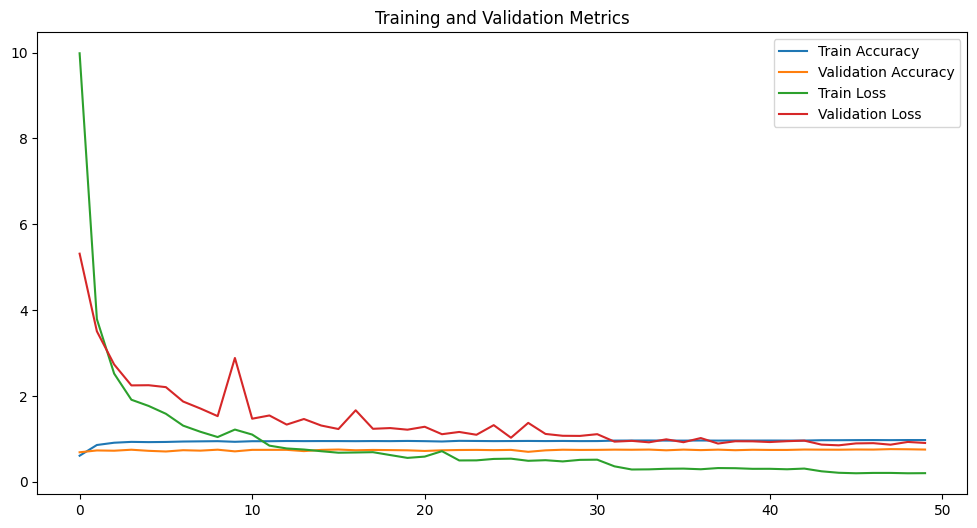

In [85]:
# Plot Training History
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training and Validation Metrics')
plt.show()


In [87]:
# Assuming 'val_generator' is your validation data generator
y_true = val_generator.classes  # True labels
y_pred = model.predict(val_generator)  # Predictions
y_pred = np.argmax(y_pred, axis=1)  # Convert predictions to class labels

86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step


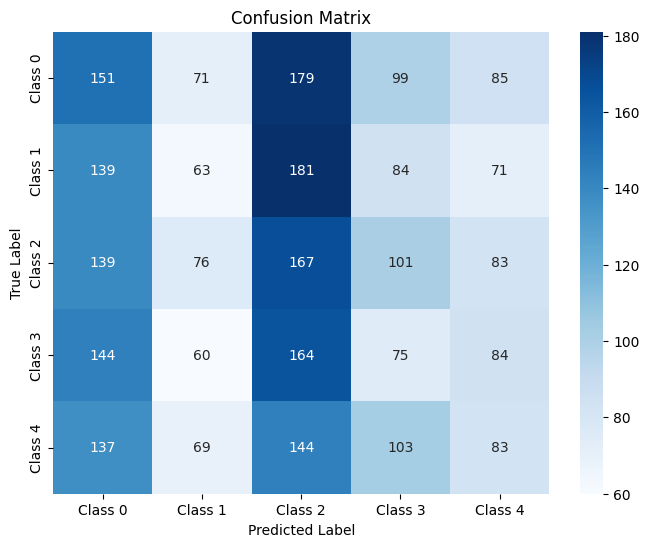

In [89]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'],
            yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [93]:
# Print one batch of data
inputs, labels = next(train_generator)
print("Inputs shape:", inputs.shape)  # Should be (batch_size, height, width, channels)
print("Labels shape:", labels.shape)  # Should be (batch_size, num_classes)


Inputs shape: (32, 224, 224, 3)
Labels shape: (32, 5)


In [95]:
print("Class weights:", class_weight_dict)
print("Classes in train_generator:", train_generator.class_indices)


Class weights: {0: 0.9415384615384615, 1: 1.022841225626741, 2: 0.9722859664607237, 3: 1.0451612903225806, 4: 1.0256983240223463}
Classes in train_generator: {'class_0': 0, 'class_1': 1, 'class_2': 2, 'class_3': 3, 'class_4': 4}


In [97]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,834,641 (254.95 MB)

 Trainable params: 22,278,213 (84.98 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,556,428 (169.97 MB)

In [103]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Load EfficientNetB0 as the base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers initially
base_model.trainable = False

# Add custom classification layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

# Build the complete model
model = Model(inputs=base_model.input, outputs=output)


In [105]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [107]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,  # Train for fewer epochs initially
    callbacks=[early_stopping, model_checkpoint, lr_scheduler]
)


Epoch 1/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 217s 602ms/step - accuracy: 0.8841 - loss: 0.3429 - val_accuracy: 0.7689 - val_loss: 0.6379 - learning_rate: 0.0010
Epoch 2/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 205s 594ms/step - accuracy: 0.9679 - loss: 0.0976 - val_accuracy: 0.7860 - val_loss: 0.5549 - learning_rate: 0.0010
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 202s 586ms/step - accuracy: 0.9647 - loss: 0.0982 - val_accuracy: 0.7816 - val_loss: 0.5576 - learning_rate: 0.0010
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 198s 573ms/step - accuracy: 0.9693 - loss: 0.0897 - val_accuracy: 0.7754 - val_loss: 0.5973 - learning_rate: 0.0010
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 198s 573ms/step - accuracy: 0.9743 - loss: 0.0816 - val_accuracy: 0.7914 - val_loss: 0.5231 - learning_rate: 0.0010
Epoch 6/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 206s 597ms/step - accuracy: 0.9736 - loss: 0.0768 - val_accuracy: 0.7980 - val_loss: 0.5100 - learning_rate: 0.0010
Epoch 7/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 203s 589ms/step - accura

In [108]:
# Unfreeze the base model layers
base_model.trainable = True

# Compile the model with a lower learning rate for fine-tuning
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Lower learning rate for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the entire model
history_fine_tune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,  # Fine-tuning epochs
    callbacks=[early_stopping, model_checkpoint, lr_scheduler]
)


Epoch 1/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1140s 3s/step - accuracy: 0.8069 - loss: 0.9700 - val_accuracy: 0.7209 - val_loss: 1.0007 - learning_rate: 1.0000e-05
Epoch 2/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1128s 3s/step - accuracy: 0.9544 - loss: 0.1744 - val_accuracy: 0.7464 - val_loss: 1.1679 - learning_rate: 1.0000e-05
Epoch 3/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1152s 3s/step - accuracy: 0.9592 - loss: 0.1320 - val_accuracy: 0.7547 - val_loss: 1.0456 - learning_rate: 1.0000e-05
Epoch 4/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1092s 3s/step - accuracy: 0.9699 - loss: 0.0984 - val_accuracy: 0.7609 - val_loss: 1.1756 - learning_rate: 1.0000e-05
Epoch 5/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 1106s 3s/step - accuracy: 0.9709 - loss: 0.0863 - val_accuracy: 0.7653 - val_loss: 1.5422 - learning_rate: 1.0000e-05
Epoch 6/20
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9705 - loss: 0.0858
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
345/345 ━━━━━━━━━━━━━━━━━━━━ 1114s 3s/step - accu

In [109]:
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss}")
print(f"Validation Accuracy: {accuracy}")

86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 499ms/step - accuracy: 0.7134 - loss: 1.0286
Validation Loss: 1.0007178783416748
Validation Accuracy: 0.7209302186965942


In [110]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict on the validation set
val_preds = model.predict(val_generator)
val_pred_classes = np.argmax(val_preds, axis=1)
val_true_classes = val_generator.classes

# Classification report
print(classification_report(val_true_classes, val_pred_classes))

# Confusion matrix
cm = confusion_matrix(val_true_classes, val_pred_classes)
print(cm)


86/86 ━━━━━━━━━━━━━━━━━━━━ 46s 492ms/step
              precision    recall  f1-score   support

           0       0.21      0.26      0.23       585
           1       0.20      0.12      0.15       538
           2       0.20      0.22      0.21       566
           3       0.18      0.17      0.18       527
           4       0.19      0.21      0.20       536

    accuracy                           0.20      2752
   macro avg       0.20      0.20      0.19      2752
weighted avg       0.20      0.20      0.19      2752

[[152  67 133 113 120]
 [138  62 123 102 113]
 [145  56 125 103 137]
 [139  63 119  92 114]
 [153  64 116  91 112]]


In [268]:
# Build fine-tuned model
fine_tuned_model = build_fine_tuned_model()
model.summary()
# Compile the model
fine_tuned_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,508,817 (127.83 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,339,212 (85.22 MB)

In [270]:
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('fine_tuned_model.keras', monitor='val_loss', save_best_only=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)

# Train the fine-tuned model
fine_tuned_history = fine_tuned_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping, model_checkpoint, lr_scheduler]
)


Epoch 1/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 138s 398ms/step - accuracy: 0.5386 - loss: 34.7833 - val_accuracy: 0.6875 - val_loss: 3.3915 - learning_rate: 0.0010
Epoch 2/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 140s 407ms/step - accuracy: 0.7852 - loss: 3.0572 - val_accuracy: 0.7017 - val_loss: 2.9063 - learning_rate: 0.0010
Epoch 3/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 132s 382ms/step - accuracy: 0.8681 - loss: 2.2197 - val_accuracy: 0.7261 - val_loss: 2.5695 - learning_rate: 0.0010
Epoch 4/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 137s 399ms/step - accuracy: 0.8525 - loss: 2.5783 - val_accuracy: 0.7141 - val_loss: 3.2083 - learning_rate: 0.0010
Epoch 5/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 155s 451ms/step - accuracy: 0.8849 - loss: 2.3992 - val_accuracy: 0.7046 - val_loss: 2.3768 - learning_rate: 0.0010
Epoch 6/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 137s 397ms/step - accuracy: 0.9124 - loss: 1.6235 - val_accuracy: 0.7272 - val_loss: 1.8825 - learning_rate: 0.0010
Epoch 7/20
344/344 ━━━━━━━━━━━━━━━━━━━━ 136s 394ms/step - accur

86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.7674 - loss: 1.0564
Validation Accuracy: 76.10%
Validation Loss: 1.0984
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step

Classification Report:
              precision    recall  f1-score   support

     class_0       0.20      0.23      0.21       586
     class_1       0.19      0.12      0.14       538
     class_2       0.20      0.33      0.25       563
     class_3       0.18      0.15      0.16       529
     class_4       0.21      0.16      0.18       533

    accuracy                           0.20      2749
   macro avg       0.20      0.20      0.19      2749
weighted avg       0.20      0.20      0.19      2749



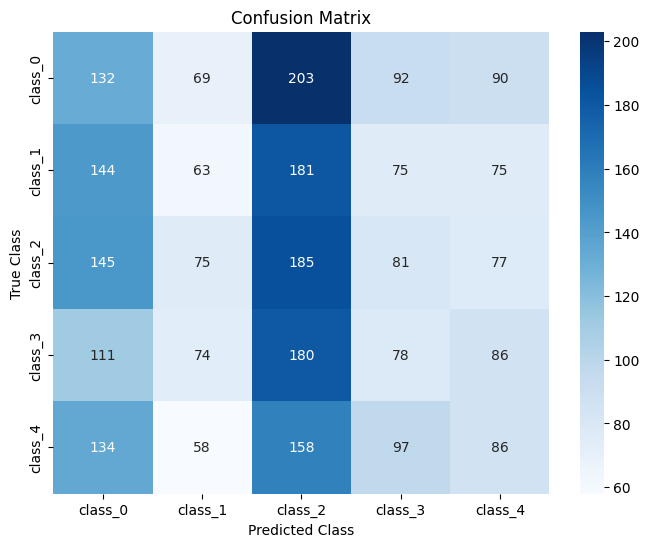

In [280]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on validation data
val_loss, val_accuracy = fine_tuned_model.evaluate(val_generator)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Validation Loss: {val_loss:.4f}")

# Generate predictions
y_true = val_generator.classes
y_pred = fine_tuned_model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=val_generator.class_indices.keys()))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()


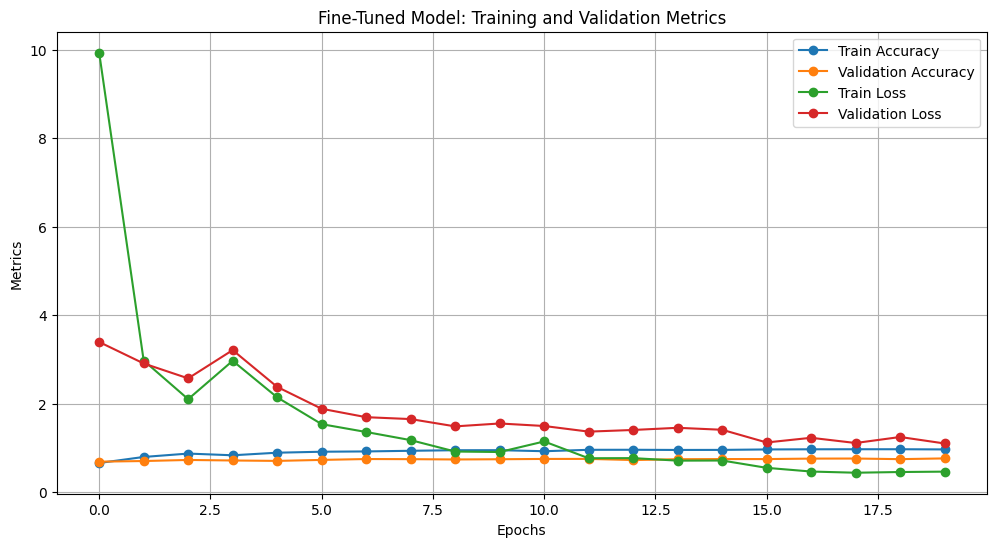

In [282]:
# Plot fine-tuning metrics
plt.figure(figsize=(12, 6))
plt.plot(fine_tuned_history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(fine_tuned_history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.plot(fine_tuned_history.history['loss'], label='Train Loss', marker='o')
plt.plot(fine_tuned_history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Fine-Tuned Model: Training and Validation Metrics')
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.legend()
plt.grid(True)
plt.show()


In [288]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Load the ResNet50 base model (pre-trained on ImageNet)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)  # Regularization
predictions = Dense(5, activation='softmax')(x)

# Define the final model
transfer_learning_model = Model(inputs=base_model.input, outputs=predictions)
transfer_learning_model.summary()
# Compile the model
transfer_learning_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_12[0… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 36,433,541 (138.98 MB)

 Trainable params: 12,845,829 (49.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [9]:
import os
import cv2
from tqdm import tqdm

# Paths
input_folder = r"C:\Users\mouli\Downloads\aptos2019-blindness-detection\enhanced_train"
output_folder = r"C:\Users\mouli\Downloads\aptos2019-blindness-detection\final_train"
os.makedirs(output_folder, exist_ok=True)

# Target size
output_size = (256, 256)

# CLAHE parameters
clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))

# Function for preprocessing
def preprocess_images(input_folder, output_folder, output_size, clahe):
    print("Starting Preprocessing (256x256)...")
    for class_name in os.listdir(input_folder):
        class_input_path = os.path.join(input_folder, class_name)
        class_output_path = os.path.join(output_folder, class_name)
        os.makedirs(class_output_path, exist_ok=True)

        print(f"\nProcessing {class_name}...")
        for img_name in tqdm(os.listdir(class_input_path), desc=f"Processing {class_name}"):
            input_path = os.path.join(class_input_path, img_name)
            output_path = os.path.join(class_output_path, img_name)

            try:
                # Read image
                img = cv2.imread(input_path)

                # Convert to LAB color space and apply CLAHE
                lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
                l, a, b = cv2.split(lab)
                cl = clahe.apply(l)
                merged = cv2.merge((cl, a, b))
                img = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

                # Resize to 256x256
                img = cv2.resize(img, output_size)

                # Save preprocessed image
                cv2.imwrite(output_path, img)
            except Exception as e:
                print(f"Error processing {img_name}: {e}")

    print("\nPreprocessing Completed (256x256)!")
    
# Run the preprocessing
preprocess_images(input_folder, output_folder, output_size, clahe)


Starting Preprocessing (256x256)...

Processing class_0...


Processing class_0: 100%|██████████| 1794/1794 [00:08<00:00, 204.29it/s]



Processing class_1...


Processing class_1: 100%|██████████| 368/368 [00:01<00:00, 191.73it/s]



Processing class_2...


...


Processing class_3...


Processing class_3: 100%|██████████| 192/192 [00:00<00:00, 195.57it/s]



Processing class_4...


Processing class_4: 100%|██████████| 293/293 [00:01<00:00, 199.08it/s]


Preprocessing Completed (256x256)!


In [10]:
import os
import cv2

# Path to final preprocessed dataset
final_folder = r"C:\Users\mouli\Downloads\aptos2019-blindness-detection\final_train"

# Check dimensions
def verify_image_dimensions(folder_path, target_size=(256, 256)):
    mismatched_images = []
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        for img_name in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_name)
            img = cv2.imread(img_path)
            if img.shape[:2] != target_size:
                mismatched_images.append((class_name, img_name, img.shape[:2]))
    return mismatched_images

# Run verification
mismatched_images = verify_image_dimensions(final_folder)
if mismatched_images:
    print("Mismatched Images Found:")
    for class_name, img_name, dim in mismatched_images[:10]:  # Show first 10
        print(f"Class: {class_name}, Image: {img_name}, Dimensions: {dim}")
else:
    print("All images are correctly resized to 256x256.")


All images are correctly resized to 256x256.



Visualizing Preprocessed Images...

Class: class_0


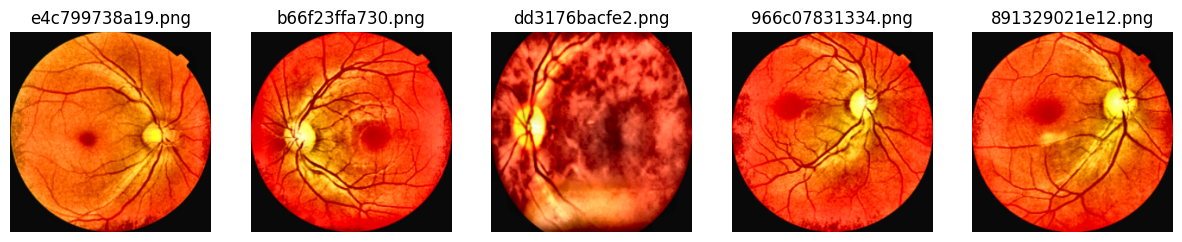


Class: class_1


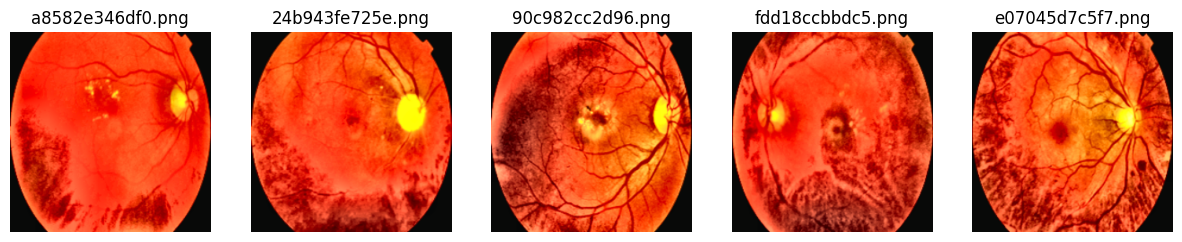


Class: class_2


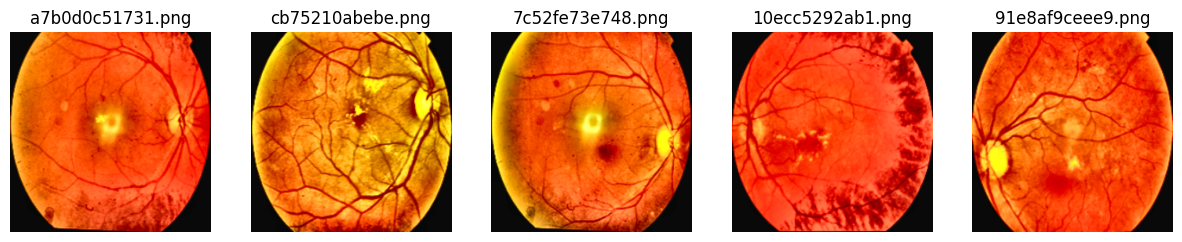


Class: class_3


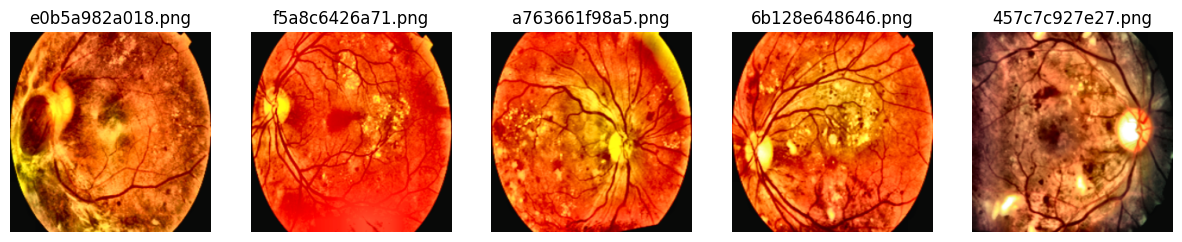


Class: class_4


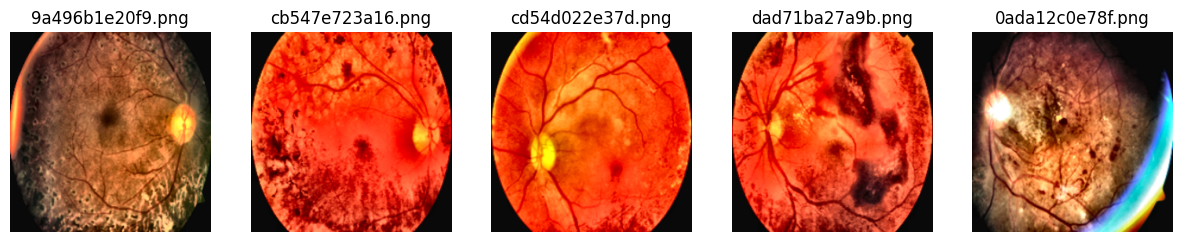

In [13]:
import matplotlib.pyplot as plt
import random

# Visualize images
def visualize_preprocessed_images(folder_path, num_samples=5):
    print("\nVisualizing Preprocessed Images...")
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        sample_images = random.sample(os.listdir(class_folder), num_samples)

        print(f"\nClass: {class_name}")
        plt.figure(figsize=(15, 5))
        for i, img_name in enumerate(sample_images):
            img_path = os.path.join(class_folder, img_name)
            img = plt.imread(img_path)
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            plt.title(img_name)
            plt.axis('off')
        plt.show()

# Visualize samples
visualize_preprocessed_images(final_folder)


In [15]:
def count_images_per_class(folder_path):
    class_counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        class_counts[class_name] = len(os.listdir(class_folder))
    return class_counts

# Run count verification
class_counts = count_images_per_class(final_folder)
print("\nClass Counts Verification:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")



Class Counts Verification:
class_0: 1794 images
class_1: 368 images
class_2: 985 images
class_3: 192 images
class_4: 293 images


In [19]:
import shutil

def oversample_class(folder_path, target_count):
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        current_count = len(os.listdir(class_folder))
        while current_count < target_count:
            for img_name in os.listdir(class_folder):
                src_path = os.path.join(class_folder, img_name)
                dst_path = os.path.join(class_folder, f"dup_{current_count}.jpg")
                shutil.copy(src_path, dst_path)
                current_count += 1
                if current_count >= target_count:
                    break

oversample_class(final_folder, target_count=1794)  # Match all classes to the largest

In [21]:
def count_images_per_class(folder_path):
    class_counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        class_counts[class_name] = len(os.listdir(class_folder))
    return class_counts

# Check class counts after applying SMOTE
balanced_class_counts = count_images_per_class(final_folder)
print("\nClass Counts After SMOTE:")
for class_name, count in balanced_class_counts.items():
    print(f"{class_name}: {count} images")



Class Counts After SMOTE:
class_0: 1794 images
class_1: 1794 images
class_2: 1794 images
class_3: 1794 images
class_4: 1794 images


In [23]:
import cv2

def verify_image_dimensions(folder_path, target_size=(256, 256)):
    mismatched_images = []
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        for img_name in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_name)
            img = cv2.imread(img_path)
            if img.shape[:2] != target_size:
                mismatched_images.append((class_name, img_name, img.shape[:2]))
    return mismatched_images

# Verify dimensions
mismatched_images = verify_image_dimensions(final_folder)
if mismatched_images:
    print("\nMismatched Images Found:")
    for class_name, img_name, dim in mismatched_images[:10]:  # Show first 10
        print(f"Class: {class_name}, Image: {img_name}, Dimensions: {dim}")
else:
    print("\nAll images are correctly resized to 256x256.")



All images are correctly resized to 256x256.


In [42]:
from PIL import Image

# Check a few random images
import random
class_names = os.listdir(final_folder)
for class_name in class_names:
    class_folder = os.path.join(final_folder, class_name)
    random_image = random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, random_image)
    img = Image.open(img_path)
    img.show()


In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parameters
image_size = (224, 224)  # Ensure the size matches your model input
batch_size = 32

# Data Generators
datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)  # Rescale pixel values

train_generator = datagen.flow_from_directory(
    final_folder,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    final_folder,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Confirm the class indices
print("Class Indices:", train_generator.class_indices)


Found 7180 images belonging to 5 classes.
Found 1790 images belonging to 5 classes.
Class Indices: {'class_0': 0, 'class_1': 1, 'class_2': 2, 'class_3': 3, 'class_4': 4}


In [46]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Load EfficientNetB0 as the base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers initially
base_model.trainable = False

# Add custom classification layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

# Build the complete model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # Reduced learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print the model summary
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_3     │ (None, 224, 224,  │          7 │ rescaling_6[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 224, 224,  │          0 │ normalization_3[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_7[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,411,048 (16.83 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

# A simple CNN model for debugging
simple_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')  # 5 classes
])

simple_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the simple model
simple_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5  # Only a few epochs to test learning
)

Epoch 1/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 123s 544ms/step - accuracy: 0.4473 - loss: 4.6881 - val_accuracy: 0.8883 - val_loss: 0.4102
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 123s 548ms/step - accuracy: 0.9255 - loss: 0.2848 - val_accuracy: 0.9508 - val_loss: 0.1670
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 122s 542ms/step - accuracy: 0.9724 - loss: 0.1102 - val_accuracy: 0.9670 - val_loss: 0.1380
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 123s 546ms/step - accuracy: 0.9764 - loss: 0.0939 - val_accuracy: 0.9564 - val_loss: 0.1654
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 123s 547ms/step - accuracy: 0.9792 - loss: 0.0880 - val_accuracy: 0.9732 - val_loss: 0.1030
